In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

orders = pd.read_csv('olist_orders_dataset.csv', parse_dates=[
    'order_purchase_timestamp', 'order_approved_at', 
    'order_delivered_carrier_date', 'order_delivered_customer_date', 
    'order_estimated_delivery_date'
])
items = pd.read_csv('olist_order_items_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
geo = pd.read_csv('olist_geolocation_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
category_translation = pd.read_csv('product_category_name_translation.csv')

print("All files loaded:")
print(f"orders: {orders.shape}, items: {items.shape}, payments: {payments.shape}")
print(f"reviews: {reviews.shape}, customers: {customers.shape}, geo: {geo.shape}")
print(f"products: {products.shape}, sellers: {sellers.shape}, category_translation: {category_translation.shape}")

All files loaded:
orders: (99441, 8), items: (112650, 7), payments: (103886, 5)
reviews: (99224, 7), customers: (99441, 5), geo: (1000163, 5)
products: (32951, 9), sellers: (3095, 4), category_translation: (71, 2)


In [2]:
print("="*60)
print("DATA QUALITY CHECKS")
print("="*60)

for name, df in [('orders', orders), ('items', items), ('payments', payments),
                  ('reviews', reviews), ('customers', customers),
                  ('products', products), ('sellers', sellers)]:
    print(f"\n{name}: {df.shape}")
    missing = df.isna().sum()
    missing = missing[missing > 0]
    if len(missing):
        print(missing)
    else:
        print("No missing values")

print("\norder_status distribution:")
print(orders['order_status'].value_counts())

print("\nprice / freight_value outlier check:")
print(items[['price', 'freight_value']].describe())

print("\nTop 5 highest freight_value rows (sanity check for data entry errors):")
print(items.sort_values('freight_value', ascending=False)[['order_id','price','freight_value']].head())

print("\nDuplicate check across key tables (order_id should be unique per order):")
print(f"orders duplicated order_id: {orders['order_id'].duplicated().sum()}")
print(f"reviews duplicated order_id: {reviews['order_id'].duplicated().sum()} (expected > 0, handled in next cell)")
print(f"customers duplicated customer_id: {customers['customer_id'].duplicated().sum()}")

DATA QUALITY CHECKS

orders: (99441, 8)
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

items: (112650, 7)
No missing values

payments: (103886, 5)
No missing values

reviews: (99224, 7)
review_comment_title      87656
review_comment_message    58247
dtype: int64

customers: (99441, 5)
No missing values

products: (32951, 9)
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

sellers: (3095, 4)
No missing values

order_status distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

price / freight_value outlier chec

In [3]:
# Aggregate items to order level
items_agg = items.groupby('order_id').agg({
    'price': 'sum',
    'freight_value': 'sum',
    'product_id': 'nunique',
    'seller_id': 'nunique'
}).rename(columns={
    'price': 'total_order_value',
    'freight_value': 'total_freight',
    'product_id': 'unique_product_count',
    'seller_id': 'unique_seller_count'
}).reset_index()

# --- FIXED payment aggregation: dominant payment type by value, not concatenation ---
payment_counts = payments.groupby('order_id').size()
multi_payment_orders = payment_counts[payment_counts > 1].index
print(f"Orders with multiple payment records: {len(multi_payment_orders)}")

dominant_payment = (
    payments.sort_values('payment_value', ascending=False)
    .groupby('order_id')
    .first()['payment_type']
)
payments_agg = payments.groupby('order_id').agg({
    'payment_value': 'sum',
    'payment_installments': 'max'
}).rename(columns={'payment_value': 'total_paid'}).reset_index()
payments_agg = payments_agg.merge(dominant_payment.rename('payment_type'), on='order_id', how='left')
payments_agg['is_mixed_payment'] = payments_agg['order_id'].isin(multi_payment_orders)

print("\npayment_type distribution after fix (should have no combo-strings):")
print(payments_agg['payment_type'].value_counts())

# --- FIXED reviews aggregation: dedupe to one row per order_id ---
print(f"\nReviews before dedup: {len(reviews)}")
print(f"Unique order_ids in reviews: {reviews['order_id'].nunique()}")
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])
reviews_dedup = reviews.sort_values('review_answer_timestamp').groupby('order_id').last().reset_index()
print(f"Reviews after dedup: {len(reviews_dedup)}")

# Compress geolocation
geo_agg = geo.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()

# Build master table
master = orders.copy()
master = master.merge(items_agg, on='order_id', how='left')
master = master.merge(payments_agg, on='order_id', how='left')
master = master.merge(reviews_dedup, on='order_id', how='left')
master = master.merge(customers, on='customer_id', how='left')
master = master.merge(geo_agg, left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='left')
master.drop('geolocation_zip_code_prefix', axis=1, inplace=True, errors='ignore')

# Assert no row explosion from the merges
assert master.shape[0] == orders.shape[0], f"Row count changed! {master.shape[0]} vs {orders.shape[0]}"
print(f"\nMaster shape confirmed: {master.shape}")

# Feature engineering
master['delivery_delta'] = (master['order_delivered_customer_date'] - master['order_estimated_delivery_date']).dt.days
master['is_delivered'] = master['order_status'] == 'delivered'

# Explicit check: is_delivered doesn't guarantee complete timestamps
delivered_missing_date = master[(master['is_delivered']) & (master['order_delivered_customer_date'].isna())]
print(f"\nDelivered orders missing actual delivery date: {len(delivered_missing_date)}")
if len(delivered_missing_date):
    print("Review score distribution for these rows (check if systematically different):")
    print(delivered_missing_date['review_score'].value_counts(normalize=True).sort_index())
    print("vs. overall delivered review score distribution:")
    print(master[master['is_delivered']]['review_score'].value_counts(normalize=True).sort_index())

master.to_csv('olist_master_clean_data.csv', index=False)
print("\nMaster saved as 'olist_master_clean_data.csv'")

Orders with multiple payment records: 2961

payment_type distribution after fix (should have no combo-strings):
payment_type
credit_card    74975
boleto         19784
voucher         3151
debit_card      1527
not_defined        3
Name: count, dtype: int64

Reviews before dedup: 99224
Unique order_ids in reviews: 98673
Reviews after dedup: 98673

Master shape confirmed: (99441, 28)

Delivered orders missing actual delivery date: 8
Review score distribution for these rows (check if systematically different):
review_score
1.0    0.125
5.0    0.875
Name: proportion, dtype: float64
vs. overall delivered review score distribution:
review_score
1.0    0.097587
2.0    0.030480
3.0    0.082603
4.0    0.197095
5.0    0.592234
Name: proportion, dtype: float64

Master saved as 'olist_master_clean_data.csv'


In [4]:
items_with_cat = items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
items_with_cat = items_with_cat.merge(category_translation, on='product_category_name', how='left')
order_categories = items_with_cat.groupby('order_id')['product_category_name_english'].first().reset_index()

print(f"order_categories built: {order_categories.shape}")
print(order_categories.head())

order_categories built: (98666, 2)
                           order_id product_category_name_english
0  00010242fe8c5a6d1ba2dd792cb16214                    cool_stuff
1  00018f77f2f0320c557190d7a144bdd3                      pet_shop
2  000229ec398224ef6ca0657da4fc703e               furniture_decor
3  00024acbcdf0a6daa1e931b038114c75                     perfumery
4  00042b26cf59d7ce69dfabb4e55b4fd9                  garden_tools


In [5]:
print("="*60)
print("REVIEW TIMING VS ACTUAL DELIVERY CHECK")
print("="*60)

check = master[master['is_delivered'] & master['order_delivered_customer_date'].notna() & master['review_creation_date'].notna()].copy()
check['review_creation_date'] = pd.to_datetime(check['review_creation_date'])

check['review_before_delivery'] = check['review_creation_date'] < check['order_delivered_customer_date']

pct_before = check['review_before_delivery'].mean() * 100
print(f"% of reviews created BEFORE the customer's actual delivery date: {pct_before:.1f}%")

print("\nReview score distribution when review precedes delivery:")
print(check[check['review_before_delivery']]['review_score'].value_counts(normalize=True).sort_index())

print("\nReview score distribution when review comes after delivery:")
print(check[~check['review_before_delivery']]['review_score'].value_counts(normalize=True).sort_index())

REVIEW TIMING VS ACTUAL DELIVERY CHECK
% of reviews created BEFORE the customer's actual delivery date: 8.5%

Review score distribution when review precedes delivery:
review_score
1.0    0.430713
2.0    0.068673
3.0    0.092015
4.0    0.119042
5.0    0.289558
Name: proportion, dtype: float64

Review score distribution when review comes after delivery:
review_score
1.0    0.066660
2.0    0.026938
3.0    0.081737
4.0    0.204359
5.0    0.620307
Name: proportion, dtype: float64


First few months (check for partial/truncated data):
  order_month  order_count    revenue  avg_review
0  2016-09-01            4     267.36    1.000000
1  2016-10-01          324   49507.66    3.561129
2  2016-12-01            1      10.90    5.000000
3  2017-01-01          800  120312.87    4.062025
4  2017-02-01         1780  247303.02    4.016403

Last few months (check for partial/truncated data):
   order_month  order_count    revenue  avg_review
20  2018-06-01         6167  865124.31    4.277479
21  2018-07-01         6292  895507.22    4.263006
22  2018-08-01         6512  854686.33    4.256130
23  2018-09-01           16     145.00    1.800000
24  2018-10-01            4       0.00    2.250000


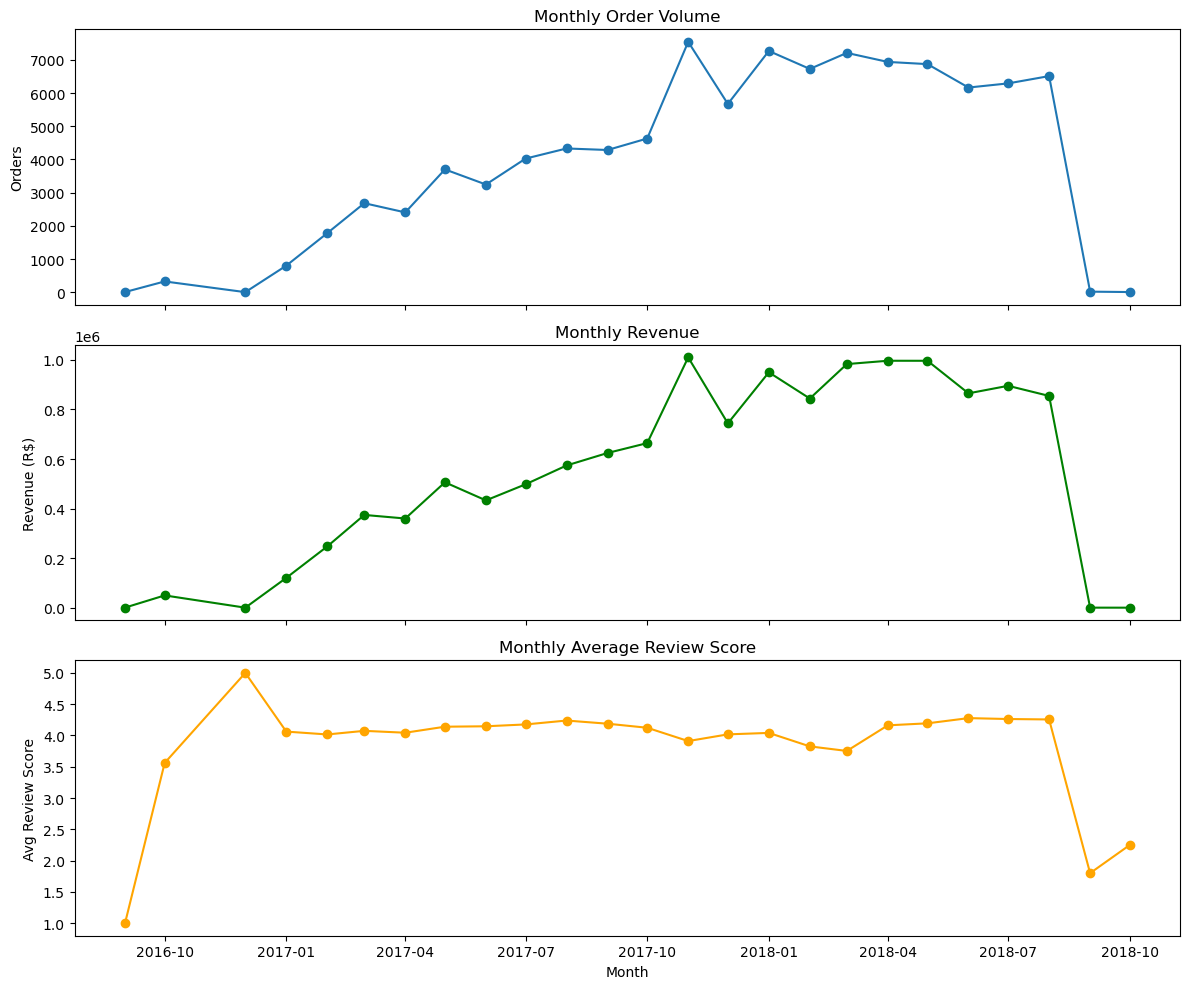


Correlation between monthly order volume and avg review score: 0.472


In [6]:
import matplotlib.pyplot as plt

master['order_month'] = master['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()

monthly = master.groupby('order_month').agg(
    order_count=('order_id', 'count'),
    revenue=('total_order_value', 'sum'),
    avg_review=('review_score', 'mean')
).reset_index()

print("First few months (check for partial/truncated data):")
print(monthly.head())
print("\nLast few months (check for partial/truncated data):")
print(monthly.tail())

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(monthly['order_month'], monthly['order_count'], marker='o')
axes[0].set_title('Monthly Order Volume')
axes[0].set_ylabel('Orders')

axes[1].plot(monthly['order_month'], monthly['revenue'], marker='o', color='green')
axes[1].set_title('Monthly Revenue')
axes[1].set_ylabel('Revenue (R$)')

axes[2].plot(monthly['order_month'], monthly['avg_review'], marker='o', color='orange')
axes[2].set_title('Monthly Average Review Score')
axes[2].set_ylabel('Avg Review Score')
axes[2].set_xlabel('Month')

plt.tight_layout()
plt.show()

corr_vol_review = monthly['order_count'].corr(monthly['avg_review'])
print(f"\nCorrelation between monthly order volume and avg review score: {corr_vol_review:.3f}")

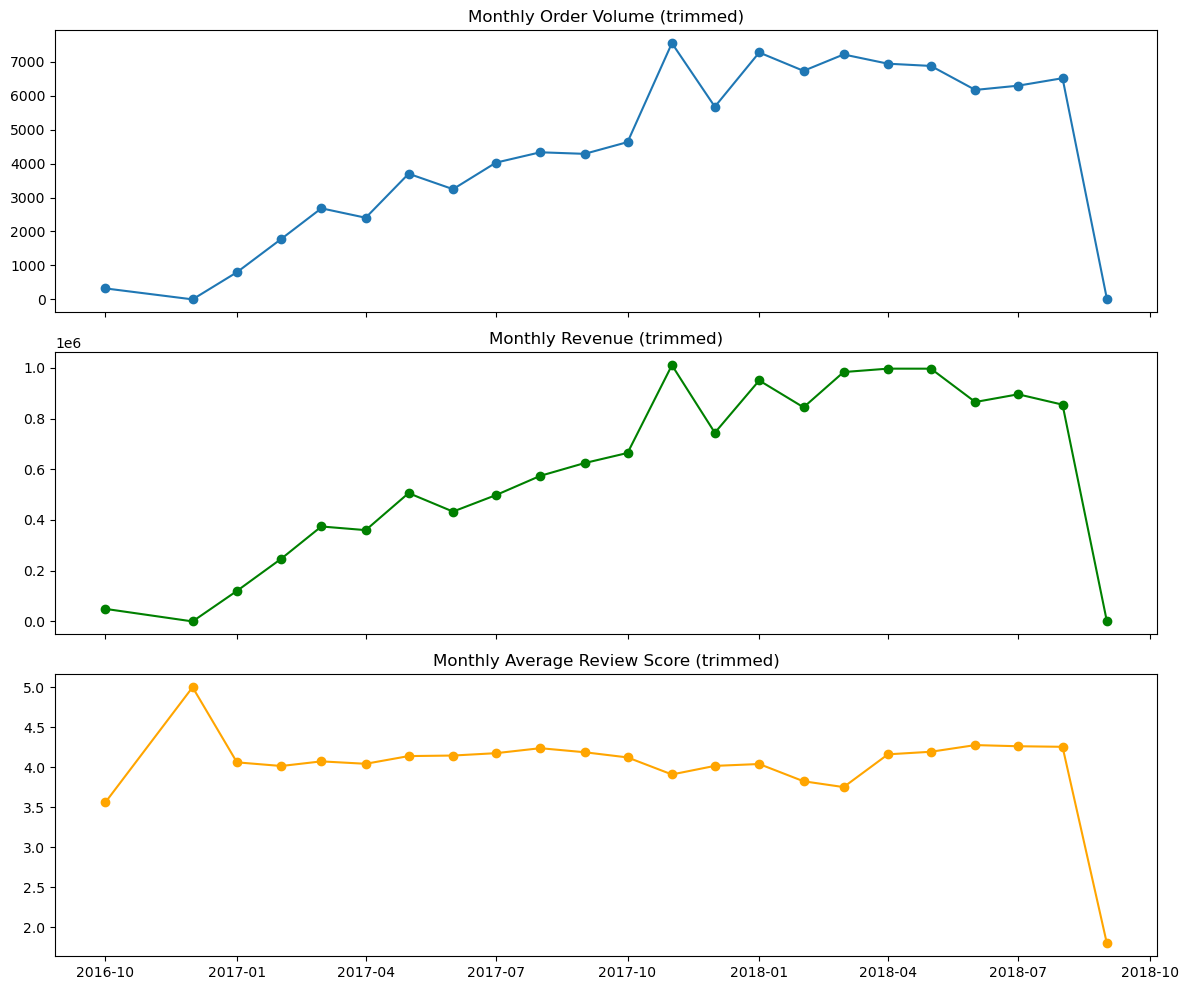

In [7]:
# Only run this if head()/tail() showed partial first/last months
monthly_trimmed = monthly.iloc[1:-1]  # adjust slicing based on what you saw

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
axes[0].plot(monthly_trimmed['order_month'], monthly_trimmed['order_count'], marker='o')
axes[0].set_title('Monthly Order Volume (trimmed)')
axes[1].plot(monthly_trimmed['order_month'], monthly_trimmed['revenue'], marker='o', color='green')
axes[1].set_title('Monthly Revenue (trimmed)')
axes[2].plot(monthly_trimmed['order_month'], monthly_trimmed['avg_review'], marker='o', color='orange')
axes[2].set_title('Monthly Average Review Score (trimmed)')
plt.tight_layout()
plt.show()

Review score by state x delay bucket (sample):
delay_bucket    Early (1-6 days)  Late (1-7 days)   On Time  Unknown  \
customer_state                                                         
AC                      3.250000         3.000000       NaN      NaN   
AL                      4.096774         2.302326  3.900000      NaN   
AM                      4.875000         3.000000  4.500000      NaN   
AP                           NaN         4.000000  5.000000      NaN   
BA                      3.981959         2.727723  3.932203      NaN   
CE                      4.097403         2.952381  3.550000      NaN   
DF                      4.109804         2.236842  4.137931      NaN   
ES                      4.011952         2.818182  4.241379      NaN   
GO                      4.112554         2.577465  3.741935      NaN   
MA                      3.920000         2.700000  4.200000      NaN   

delay_bucket    Very Early (7+ days)  Very Late (7+ days)  
customer_state              

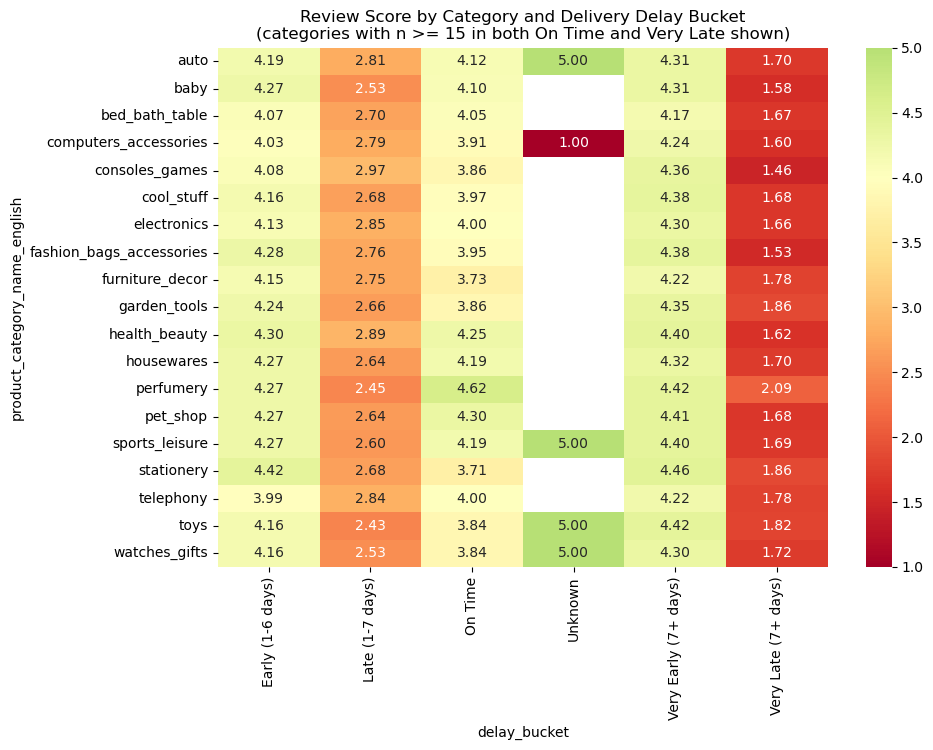


Drop in review score (Very Late vs On Time) by category, reliable categories only:
product_category_name_english
health_beauty              -2.630952
pet_shop                   -2.623529
perfumery                  -2.524476
baby                       -2.518343
sports_leisure             -2.503527
housewares                 -2.483971
auto                       -2.423279
fashion_bags_accessories   -2.415454
consoles_games             -2.392857
bed_bath_table             -2.377869
electronics                -2.342466
computers_accessories      -2.305853
cool_stuff                 -2.285924
telephony                  -2.218182
watches_gifts              -2.112795
toys                       -2.019818
garden_tools               -1.998447
furniture_decor            -1.948348
stationery                 -1.852747
dtype: float64


In [8]:
import seaborn as sns

def delay_bucket(days):
    if pd.isna(days):
        return 'Unknown'
    elif days <= -7:
        return 'Very Early (7+ days)'
    elif days < 0:
        return 'Early (1-6 days)'
    elif days == 0:
        return 'On Time'
    elif days <= 7:
        return 'Late (1-7 days)'
    else:
        return 'Very Late (7+ days)'

master['delay_bucket'] = master['delivery_delta'].apply(delay_bucket)
delivered = master[master['is_delivered'] & master['review_score'].notna()]

MIN_CELL_N = 15

# By region (state)
region_delay = delivered.groupby(['customer_state', 'delay_bucket'])['review_score'].mean().unstack()
region_bucket_counts = delivered.groupby(['customer_state', 'delay_bucket']).size().unstack()

print("Review score by state x delay bucket (sample):")
print(region_delay.head(10))

print("\nSample size behind 'On Time' and 'Very Late' columns by state:")
print(region_bucket_counts[['On Time', 'Very Late (7+ days)']].sort_values('Very Late (7+ days)', ascending=False))

region_valid_mask = (region_bucket_counts['On Time'] >= MIN_CELL_N) & (region_bucket_counts['Very Late (7+ days)'] >= MIN_CELL_N)
reliable_states = region_bucket_counts[region_valid_mask].index
print(f"\nStates with reliable sample size in both buckets: {len(reliable_states)} out of {len(region_bucket_counts)}")

region_delay_effect = region_delay['Very Late (7+ days)'] - region_delay['On Time']
region_delay_effect_reliable = region_delay_effect.loc[region_delay_effect.index.isin(reliable_states)]
print("\nDrop in review score (Very Late vs On Time) by state, reliable states only:")
print(region_delay_effect_reliable.sort_values())

# By category
cat_delay = delivered.merge(order_categories, on='order_id', how='left')
cat_delay_pivot = cat_delay.groupby(['product_category_name_english', 'delay_bucket'])['review_score'].mean().unstack()
cat_bucket_counts = cat_delay.groupby(['product_category_name_english', 'delay_bucket']).size().unstack()

cat_counts = cat_delay['product_category_name_english'].value_counts()
valid_cats = cat_counts[cat_counts >= 30].index
cat_delay_pivot = cat_delay_pivot.loc[cat_delay_pivot.index.isin(valid_cats)]
cat_bucket_counts = cat_bucket_counts.loc[cat_bucket_counts.index.isin(valid_cats)]

print("\nSample size behind 'On Time' and 'Very Late' columns by category:")
print(cat_bucket_counts[['On Time', 'Very Late (7+ days)']].sort_values('Very Late (7+ days)', ascending=False))

cell_valid_mask = (cat_bucket_counts['On Time'] >= MIN_CELL_N) & (cat_bucket_counts['Very Late (7+ days)'] >= MIN_CELL_N)
reliable_cats = cat_bucket_counts[cell_valid_mask].index
print(f"\nCategories with reliable sample size in both On Time and Very Late buckets: {len(reliable_cats)} out of {len(cat_bucket_counts)}")

heatmap_data = cat_delay_pivot.loc[cat_delay_pivot.index.isin(reliable_cats)]
plt.figure(figsize=(10, max(6, len(heatmap_data) * 0.4)))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn', center=4)
plt.title('Review Score by Category and Delivery Delay Bucket\n(categories with n >= 15 in both On Time and Very Late shown)')
plt.tight_layout()
plt.show()

delay_effect_by_cat = cat_delay_pivot['Very Late (7+ days)'] - cat_delay_pivot['On Time']
delay_effect_reliable = delay_effect_by_cat.loc[delay_effect_by_cat.index.isin(reliable_cats)]
print("\nDrop in review score (Very Late vs On Time) by category, reliable categories only:")
print(delay_effect_reliable.sort_values())

In [9]:
# Merge seller info into master for seller-level analysis
seller_orders = items.groupby('order_id')['seller_id'].first().reset_index()
master_with_seller = master.merge(seller_orders, on='order_id', how='left')
master_with_cat = master.merge(order_categories, on='order_id', how='left')

print("="*60)
print("WORST 10 STATES BY AVERAGE REVIEW SCORE (n >= 10)")
print("="*60)
state_avg = master[master['is_delivered'] == True].groupby('customer_state')['review_score'].agg(['mean', 'count'])
state_avg = state_avg[state_avg['count'] >= 10].sort_values('mean')
print(state_avg.head(10))

print("\n" + "="*60)
print("WORST 10 PRODUCT CATEGORIES (n >= 10)")
print("="*60)
cat_data = master_with_cat[(master_with_cat['is_delivered'] == True) & (master_with_cat['product_category_name_english'].notna())]
cat_perf = cat_data.groupby('product_category_name_english')['review_score'].agg(['mean', 'count'])
cat_perf = cat_perf[cat_perf['count'] >= 10].sort_values('mean')
print(cat_perf.head(10))
print("\nBEST 10 PRODUCT CATEGORIES:")
print(cat_perf.tail(10))

print("\n" + "="*60)
print("AVERAGE REVIEW SCORE BY PAYMENT TYPE")
print("="*60)
payment_avg = master[master['is_delivered'] == True].groupby('payment_type')['review_score'].agg(['mean', 'count']).sort_values('mean')
print(payment_avg)

print("\n" + "="*60)
print("PAYMENT INSTALLMENTS VS ORDER VALUE")
print("="*60)
installment_value = master[master['is_delivered'] == True].groupby('payment_installments').agg(
    avg_order_value=('total_order_value', 'mean'),
    avg_review=('review_score', 'mean'),
    count=('order_id', 'count')
)
print(installment_value[installment_value['count'] >= 10])

WORST 10 STATES BY AVERAGE REVIEW SCORE (n >= 10)
                    mean  count
customer_state                 
MA              3.832865    712
AL              3.847716    394
RR              3.902439     41
SE              3.907186    334
PA              3.914255    933
BA              3.930629   3229
CE              3.944226   1273
RJ              3.965441  12211
PI              3.993631    471
PB              4.076172    512

WORST 10 PRODUCT CATEGORIES (n >= 10)
                                       mean  count
product_category_name_english                     
office_furniture                   3.651294   1236
fashion_male_clothing              3.819048    105
audio                              3.847507    341
furniture_mattress_and_upholstery  3.891892     37
home_comfort_2                     3.904762     21
home_confort                       3.907609    368
fashio_female_clothing             3.916667     36
diapers_and_hygiene                3.960000     25
fixed_telephony  

In [10]:
print("All states, ranked, with sample size and stability flag:")
state_avg_full = master[master['is_delivered'] == True].groupby('customer_state')['review_score'].agg(['mean', 'count', 'std']).sort_values('mean')
state_avg_full['stable'] = state_avg_full['count'] >= 50

print(state_avg_full)

print("\nStates to report with confidence (n >= 50):")
print(state_avg_full[state_avg_full['stable']].head(10))

print("\nStates with too little data to draw conclusions (n < 50):")
print(state_avg_full[~state_avg_full['stable']])

All states, ranked, with sample size and stability flag:
                    mean  count       std  stable
customer_state                                   
MA              3.832865    712  1.464590    True
AL              3.847716    394  1.471409    True
RR              3.902439     41  1.374861   False
SE              3.907186    334  1.458251    True
PA              3.914255    933  1.428984    True
BA              3.930629   3229  1.393077    True
CE              3.944226   1273  1.407817    True
RJ              3.965441  12211  1.453945    True
PI              3.993631    471  1.384551    True
PB              4.076172    512  1.343266    True
ES              4.078720   1969  1.321107    True
PE              4.082964   1579  1.348644    True
AC              4.087500     80  1.284708    True
GO              4.105858   1946  1.289904    True
DF              4.131401   2070  1.298074    True
SC              4.133561   3519  1.289661    True
MT              4.145620    879  1.270553  

Dropped 8 rows with missing delivery_delta out of 96478

Correlation matrix (checking collinearity):
                   total_order_value  total_freight  delivery_delta
total_order_value           1.000000       0.409704       -0.014630
total_freight               0.409704       1.000000       -0.050483
delivery_delta             -0.014630      -0.050483        1.000000

Model R² on held-out test set: 0.117

                 Feature  Importance
0        delivery_delta    0.299426
1     total_order_value    0.272508
2         total_freight    0.240516
5             state_enc    0.079367
3  payment_installments    0.074849
4           payment_enc    0.033335

Combined 'order size' (value + freight) importance: 0.513


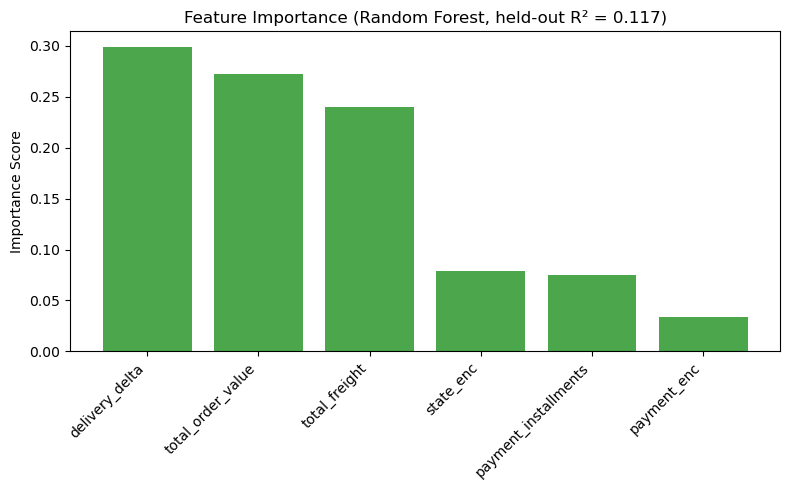

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score

model_data = master[master['is_delivered'] == True].copy()

before = len(model_data)
model_data_nonan = model_data.dropna(subset=['delivery_delta'])
print(f"Dropped {before - len(model_data_nonan)} rows with missing delivery_delta out of {before}")

features = model_data_nonan[['delivery_delta', 'total_order_value', 'total_freight', 'payment_installments']].copy()

le_pay = LabelEncoder()
le_state = LabelEncoder()
features['payment_enc'] = le_pay.fit_transform(model_data_nonan['payment_type'].fillna('unknown'))
features['state_enc'] = le_state.fit_transform(model_data_nonan['customer_state'].fillna('unknown'))

target = model_data_nonan['review_score']

clean = features.join(target).dropna()
X = clean.drop('review_score', axis=1)
y = clean['review_score']

print("\nCorrelation matrix (checking collinearity):")
print(X[['total_order_value', 'total_freight', 'delivery_delta']].corr())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"\nModel R² on held-out test set: {r2:.3f}")

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)
print("\n", importance)

combined_size_importance = importance[importance['Feature'].isin(['total_order_value', 'total_freight'])]['Importance'].sum()
print(f"\nCombined 'order size' (value + freight) importance: {combined_size_importance:.3f}")

# Visualize feature importance
plt.figure(figsize=(8, 5))
plt.bar(importance['Feature'], importance['Importance'], color='green', alpha=0.7)
plt.title('Feature Importance (Random Forest, held-out R² = %.3f)' % r2)
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [12]:
print("="*60)
print("KEY INSIGHTS SUMMARY")
print("="*60)

print("\n1. DELIVERY TIMING IS THE STRONGEST ASSOCIATED FACTOR WITH REVIEW SCORES")
print(f"   - delivery_delta shows the highest RF importance ({importance.iloc[0]['Importance']:.1%})")
print(f"   - Model R² of {r2:.2f} suggests these features explain a meaningful but partial")
print("     share of review score variation — other unmeasured factors likely matter too")
print(f"   - {pct_before:.1f}% of reviews were submitted before the recorded delivery date,")
print("     so part of this relationship may reflect delivery anxiety/uncertainty rather than")
print("     the final delay alone — worth noting as a limitation, not a clean causal read")

print("\n2. DELIVERY DELAY'S IMPACT ON REVIEWS IS BROAD, NOT CONCENTRATED")
print("   - Across states with reliable sample sizes, the 'Very Late' penalty ranges roughly")
print("     -2.0 to -2.7 stars; across categories, roughly -1.85 to -2.6 stars")
print("   - This suggests the delay-satisfaction relationship is a platform-wide pattern,")
print("     not isolated to specific regions or product types")

print("\n3. SEVERAL STATES SHOW LOWER AVERAGE REVIEW SCORES")
print("   - Only states with n >= 50 delivered+reviewed orders are treated as stable;")
print("     smaller states are directionally suggestive only")

print("\n4. SOME CATEGORIES SHOW BELOW-AVERAGE SCORES")
print("   - Worth a seller/listing-quality review in the lowest-scoring categories with")
print("     adequate sample size (see Cell 8 output)")

print("\n5. ORDER SIZE (VALUE + FREIGHT) IS ASSOCIATED WITH REVIEW SCORE")
print(f"   - Combined importance: {combined_size_importance:.1%}")
print("   - total_order_value and total_freight are correlated with each other, so treated")
print("     as one conceptual 'order size' factor rather than two independent levers")

print("\n" + "="*60)
print("RECOMMENDATIONS")
print("="*60)
print("\n1. IMPROVE DELIVERY RELIABILITY, ESPECIALLY AGAINST THE ESTIMATE")
print("   - Since the penalty is broad-based, prioritize tightening estimated delivery")
print("     date accuracy platform-wide rather than only in specific regions")
print("\n2. INVESTIGATE LOWER-PERFORMING STATES WITH ADEQUATE SAMPLE SIZE")
print("   - Focus on states in the n >= 50 stable group first")
print("\n3. REVIEW SELLER QUALITY IN LOWEST-SCORING CATEGORIES")
print("   - Prioritize categories with sufficient order volume for reliable conclusions")
print("\n4. CONSIDER SURVEY TIMING")
print(f"   - With {pct_before:.1f}% of reviews submitted before delivery is recorded,")
print("     consider delaying the review survey trigger until confirmed delivery")

KEY INSIGHTS SUMMARY

1. DELIVERY TIMING IS THE STRONGEST ASSOCIATED FACTOR WITH REVIEW SCORES
   - delivery_delta shows the highest RF importance (29.9%)
   - Model R² of 0.12 suggests these features explain a meaningful but partial
     share of review score variation — other unmeasured factors likely matter too
   - 8.5% of reviews were submitted before the recorded delivery date,
     so part of this relationship may reflect delivery anxiety/uncertainty rather than
     the final delay alone — worth noting as a limitation, not a clean causal read

2. DELIVERY DELAY'S IMPACT ON REVIEWS IS BROAD, NOT CONCENTRATED
   - Across states with reliable sample sizes, the 'Very Late' penalty ranges roughly
     -2.0 to -2.7 stars; across categories, roughly -1.85 to -2.6 stars
   - This suggests the delay-satisfaction relationship is a platform-wide pattern,
     not isolated to specific regions or product types

3. SEVERAL STATES SHOW LOWER AVERAGE REVIEW SCORES
   - Only states with n >= 50